In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import sys
sys.path.append("../..")  # Add repository root to Python path

import torch
import torch.nn as nn
from convlstm.fireseq2seq import FireSeq2Seq

In [33]:
dataset = xr.open_dataset("../../fire_pred_dataset.nc")
dataset

<xarray.Dataset> Size: 424MB
Dimensions:    (time: 62, lon: 446, lat: 210)
Coordinates:
  * time       (time) datetime64[ns] 496B 2024-12-01 2024-12-02 ... 2025-01-31
  * lon        (lon) float64 4kB -119.1 -119.1 -119.1 ... -117.6 -117.6 -117.6
  * lat        (lat) float64 2kB 34.71 34.71 34.71 34.7 ... 34.02 34.01 34.01
Data variables: (12/19)
    frp        (time, lat, lon) float32 23MB ...
    pr         (time, lat, lon) float32 23MB ...
    rmax       (time, lat, lon) float32 23MB ...
    rmin       (time, lat, lon) float32 23MB ...
    sph        (time, lat, lon) float32 23MB ...
    srad       (time, lat, lon) float32 23MB ...
    ...         ...
    fm100      (time, lat, lon) float32 23MB ...
    fm1000     (time, lat, lon) float32 23MB ...
    etr        (time, lat, lon) float32 23MB ...
    vpd        (time, lat, lon) float32 23MB ...
    lai_ave    (time, lat, lon) float32 23MB ...
    fire_mask  (time, lat, lon) int8 6MB ...
Attributes:
    description:  Combined dataset for fire prediction.
    created:      2025-04-18

In [34]:
dataset['wind_dir_normalized'] = np.sin(dataset['th'])

In [35]:
frp = torch.tensor(dataset['frp'].values, dtype=torch.float32)
fire_mask = torch.tensor(dataset['fire_mask'].values, dtype=torch.float32)
frp.shape, fire_mask.shape

(torch.Size([62, 210, 446]), torch.Size([62, 210, 446]))

In [36]:
y = fire_mask

In [37]:
import datetime

start_date = datetime.date(2024, 12, 1)
end_date = datetime.date(2025, 1, 31)
time_delta = end_date - start_date

In [38]:
0.7 * 62

43.4

In [39]:
for timestep in range(time_delta.days + 1):
    print(f"{start_date + datetime.timedelta(days=timestep)}", y[timestep,:,:].sum().item())

2024-12-01 0.0
2024-12-02 225.0
2024-12-03 30.0
2024-12-04 117.0
2024-12-05 177.0
2024-12-06 240.0
2024-12-07 270.0
2024-12-08 105.0
2024-12-09 117.0
2024-12-10 568.0
2024-12-11 268.0
2024-12-12 270.0
2024-12-13 30.0
2024-12-14 30.0
2024-12-15 120.0
2024-12-16 0.0
2024-12-17 156.0
2024-12-18 267.0
2024-12-19 204.0
2024-12-20 129.0
2024-12-21 90.0
2024-12-22 90.0
2024-12-23 30.0
2024-12-24 45.0
2024-12-25 117.0
2024-12-26 0.0
2024-12-27 150.0
2024-12-28 0.0
2024-12-29 195.0
2024-12-30 132.0
2024-12-31 150.0
2025-01-01 216.0
2025-01-02 171.0
2025-01-03 30.0
2025-01-04 30.0
2025-01-05 60.0
2025-01-06 195.0
2025-01-07 447.0
2025-01-08 2302.0
2025-01-09 1769.0
2025-01-10 1147.0
2025-01-11 660.0
2025-01-12 384.0
2025-01-13 324.0
2025-01-14 105.0
2025-01-15 99.0
2025-01-16 102.0
2025-01-17 195.0
2025-01-18 150.0
2025-01-19 135.0
2025-01-20 0.0
2025-01-21 114.0
2025-01-22 646.0
2025-01-23 426.0
2025-01-24 258.0
2025-01-25 102.0
2025-01-26 0.0
2025-01-27 0.0
2025-01-28 150.0
2025-01-29 129.0
20

In [40]:
exclude = ["th", "frp", "fire_mask", "lai_ave"]
input_vars = []
for var in dataset.data_vars:
    if var not in exclude:
        input_vars.append(var)
input_vars

['pr',
 'rmax',
 'rmin',
 'sph',
 'srad',
 'tmmn',
 'tmmx',
 'vs',
 'erc',
 'eto',
 'bi',
 'fm100',
 'fm1000',
 'etr',
 'vpd',
 'wind_dir_normalized']

In [47]:
"""
['pr',
 'rmax',
 'rmin',
 'sph',
 'srad',
 'tmmn',
 'tmmx',
 'vs',
 'erc',
 'eto',
 'bi',
 'fm100',
 'fm1000',
 'etr',
 'vpd',
 'wind_dir_normalized']
"""
X = torch.load("inputs.pt") # interpolated already
X = X[31:, :, :, :] # cut off to just january
y = fire_mask

In [48]:
# X = torch.stack([torch.tensor(dataset[input_var].values, dtype=torch.float32) for input_var in input_vars], dim=1)
X.shape

torch.Size([31, 16, 210, 446])

In [49]:
# Check for NaN values in the input data
print(f"Number of NaN values in X: {torch.isnan(X).sum().item()}")

# Function to interpolate NaN values with the average of neighboring values
def interpolate_nans(tensor):
    # Create a copy of the tensor to avoid modifying the original
    interpolated = tensor.clone()
    
    # Get the dimensions
    time_steps, features, height, width = tensor.shape
    
    # Iterate through each time step
    for t in range(time_steps):
        # Iterate through each feature
        for f in range(features):
            # Find positions with NaN values
            nan_mask = torch.isnan(tensor[t, f, :, :])
            if not torch.any(nan_mask):
                continue  # Skip if no NaNs in this feature at this time step
            
            # For each NaN position, compute the average of non-NaN neighbors
            for h in range(height):
                for w in range(width):
                    if nan_mask[h, w]:
                        # Define neighbor indices (considering boundaries)
                        h_start = max(0, h-1)
                        h_end = min(height, h+2)
                        w_start = max(0, w-1)
                        w_end = min(width, w+2)
                        
                        # Extract the neighborhoobd
                        neighborhood = tensor[t, f, h_start:h_end, w_start:w_end]
                        # Calculate mean of non-NaN neighbors
                        valid_neighbors = neighborhood[~torch.isnan(neighborhood)]
                        
                        if len(valid_neighbors) > 0:
                            # Replace NaN with mean of valid neighbors
                            interpolated[t, f, h, w] = valid_neighbors.mean()
                        else:
                            # If all neighbors are NaN, use global mean for this feature
                            feature_data = tensor[:, f, :, :]
                            global_mean = feature_data[~torch.isnan(feature_data)].mean()
                            interpolated[t, f, h, w] = global_mean
    
    return interpolated

# # Apply the interpolation
# X = interpolate_nans(X)

# # Verify that all NaN values have been interpolated
# print(f"Number of NaN values after interpolation: {torch.isnan(X).sum().item()}")

Number of NaN values in X: 0


In [50]:
# torch.save(X, "inputs.pt")

In [51]:
time_steps, features, height, width = X.shape
X.shape

torch.Size([31, 16, 210, 446])

In [52]:
# Normalize all features in X
# We'll normalize each feature independently across all time steps, locations

# Create a copy of X to store normalized values
X_normalized = X.clone()

# Normalize each feature, exclude wind direction since that's already normalized, in a different way
for f in range(features):
    # Extract the feature across all time steps and locations
    feature_data = X[:, f, :, :]
    
    # Calculate mean and standard deviation of non-NaN values
    feature_mean = feature_data.mean()
    feature_std = feature_data.std()
    
    # Normalize the feature (z-score normalization)
    X_normalized[:, f, :, :] = (feature_data - feature_mean) / feature_std

    
    print(f"Feature {f} - Mean: {feature_mean:.4f}, Std: {feature_std:.4f}")

# Replace the original X with the normalized version
X = X_normalized

print(f"Data normalized. New feature ranges:")
for f in range(features):
    feature_min = X[:, f, :, :].min().item()
    feature_max = X[:, f, :, :].max().item()
    print(f"Feature {f} - Min: {feature_min:.4f}, Max: {feature_max:.4f}")

Feature 0 - Mean: 0.8053, Std: 3.0884
Feature 1 - Mean: 48.5929, Std: 24.5787
Feature 2 - Mean: 19.2150, Std: 16.1639
Feature 3 - Mean: 0.0026, Std: 0.0014
Feature 4 - Mean: 140.0327, Std: 21.0857
Feature 5 - Mean: 277.0852, Std: 4.4670
Feature 6 - Mean: 287.9904, Std: 4.8459
Feature 7 - Mean: 3.9758, Std: 2.3323
Feature 8 - Mean: 72.2033, Std: 16.8451
Feature 9 - Mean: 2.9131, Std: 1.2066
Feature 10 - Mean: 58.9762, Std: 34.0337
Feature 11 - Mean: 8.0864, Std: 3.5083
Feature 12 - Mean: 8.0901, Std: 1.8835
Feature 13 - Mean: 4.6370, Std: 2.1292
Feature 14 - Mean: 0.9115, Std: 0.4044
Feature 15 - Mean: -0.0144, Std: 0.7136
Data normalized. New feature ranges:
Feature 0 - Min: -0.2608, Max: 12.3994
Feature 1 - Min: -1.7085, Max: 2.0915
Feature 2 - Min: -1.1269, Max: 4.9979
Feature 3 - Min: -1.6302, Max: 2.8415
Feature 4 - Min: -3.9426, Max: 1.9381
Feature 5 - Min: -4.2725, Max: 3.0254
Feature 6 - Min: -3.9395, Max: 3.0768
Feature 7 - Min: -1.4045, Max: 4.5552
Feature 8 - Min: -2.8022, Ma

In [53]:
from torch.utils.data import Dataset, DataLoader, Subset

class FireDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [54]:
def create_sequences(data, seq_length):
    sequences = []
    targets = []
    for i in range(len(data) - seq_length):
        # Extract sequence
        seq = data[i:i+seq_length]
        # Target is the next time step after the sequence
        target = y[i:i+seq_length]
        sequences.append(seq)
        targets.append(target)
    return torch.stack(sequences), torch.stack(targets)

In [55]:
def mse_nan_loss(output, target):
    # mask = ~torch.isnan(target)
    mask = (target != 0)
    sqe = (target[mask] - output[mask])**2
    return sqe.mean()

In [56]:
y.isnan().sum()

tensor(0)

In [57]:
def train_model(model, train_loader, val_loader, test_loader, optimizer, num_epochs, device="cuda"):
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    mse_loss = torch.nn.MSELoss()
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = mse_loss(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
        
        train_loss = train_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validation phase
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                
                outputs = model(inputs)
                loss = mse_loss(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        
        val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(val_loss)
        print(f'Epoch {epoch+1}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f}')
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "./ee_dataset/best_model.pth")
    
    # Final test evaluation
    model.load_state_dict(torch.load("./ee_dataset/best_model.pth"))
    model.eval()
    test_loss = 0.0
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            loss = mse_loss(outputs, targets)
            test_loss += loss.item() * inputs.size(0)
    
    test_loss = test_loss / len(test_loader.dataset)
    print(f'\nFinal Test Loss: {test_loss:.4f}')
    
    # Plot and save the training curves
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Time')
    plt.legend()
    plt.grid(True)
    
    # Save the plot
    plt.savefig('./ee_dataset/training_validation_loss.png')
    plt.close()
    
    return model

In [66]:
seq_length = 3
X_seq, y_seq = create_sequences(X, seq_length)
X_seq = torch.permute(X_seq, (0, 2, 1, 3, 4))
y_seq = torch.unsqueeze(y_seq, 1).float()

In [67]:
X_seq.shape

torch.Size([28, 16, 3, 210, 446])

In [68]:
X_seq.shape, y_seq.shape

(torch.Size([28, 16, 3, 210, 446]), torch.Size([28, 1, 3, 210, 446]))

In [69]:
y_seq = y_seq.float()

In [70]:
# Create full dataset
full_dataset = FireDataset(X_seq, y_seq)

# Calculate split indices
total_size = len(full_dataset)
train_end = int(0.7 * total_size)
val_end = train_end + int(0.1 * total_size)

# Create sequential splits
train_indices = range(0, train_end)
val_indices = range(train_end, val_end)
test_indices = range(val_end, total_size)

# Create subsets
train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)
test_dataset = Subset(full_dataset, test_indices)

# Create DataLoaders without shuffling
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [71]:
train_indices, val_indices, test_indices

(range(0, 19), range(19, 21), range(21, 28))

In [72]:
train_dataset.indices, val_dataset.indices, test_dataset.indices

(range(0, 19), range(19, 21), range(21, 28))

In [73]:
# Define model parameters
height = X.shape[2]
width = X.shape[3]
in_channels = X.shape[1]
out_channels = 1 # just 1 for frp/fire_mask
X.shape

torch.Size([31, 16, 210, 446])

In [77]:
frame_size = (height, width)
kernel_size = (3, 3)
num_layers = 1
bias = True

# Create the model
model = FireSeq2Seq(
    in_channels = in_channels,
    out_channels = out_channels,
    frame_size = frame_size,
    kernel_size = kernel_size,
    num_layers = num_layers,
    bias = bias
).to("cuda")

model

FireSeq2Seq(
  (sequential): Sequential(
    (ConvLSTM_1): ConvLSTM(
      (cell): ConvLSTMCell(
        (conv): Conv2d(80, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (BatchNorm_1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [78]:
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
mse_loss = torch.nn.MSELoss()
# Training parameters
num_epochs = 10
device = "cuda"

In [79]:
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    num_epochs=num_epochs,
    device="cuda"
)

Epoch 1/10 | Train Loss: 0.2653 | Val Loss: 0.0015
Epoch 2/10 | Train Loss: 0.0769 | Val Loss: 0.0017
Epoch 3/10 | Train Loss: 0.0474 | Val Loss: 0.0019
Epoch 4/10 | Train Loss: 0.0402 | Val Loss: 0.0019
Epoch 5/10 | Train Loss: 0.0283 | Val Loss: 0.0032
Epoch 6/10 | Train Loss: 0.0221 | Val Loss: 0.0067
Epoch 7/10 | Train Loss: 0.0186 | Val Loss: 0.0073
Epoch 8/10 | Train Loss: 0.0145 | Val Loss: 0.0056
Epoch 9/10 | Train Loss: 0.0135 | Val Loss: 0.0065
Epoch 10/10 | Train Loss: 0.0124 | Val Loss: 0.0072

Final Test Loss: 0.0017


In [ ]:
def visualize_sequence(model, dataloader, sample_idx=0, threshold=0.5):
    inputs, targets = next(iter(dataloader))
    inputs = inputs.to(device)
    targets = targets.to(device)
    
    model.eval()
    with torch.no_grad():
        predictions = model(inputs)
    
    pred = predictions[sample_idx].cpu().numpy()
    true = targets[sample_idx].cpu().numpy()
    pred_binary = (pred > threshold).astype(np.float32)
    
    seq_length = pred.shape[1]
    fig, axes = plt.subplots(2, seq_length, figsize=(5*seq_length, 10))
    
    for t in range(seq_length):
        # Prediction
        axes[0,t].imshow(pred_binary[0,t], cmap='binary')
        axes[0,t].set_title(f'Pred t={t}')
        
        # Ground truth
        axes[1,t].imshow(true[0,t], cmap='binary')
        axes[1,t].set_title(f'True t={t}')
    
    plt.tight_layout()
    plt.savefig('sequence_comparison.png', dpi=300)
    plt.show()

In [ ]:
def calculate_metrics(model, dataloader, threshold=0.5):
    model.eval()
    total_tp = total_fp = total_fn = total_tn = 0
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            preds = model(inputs)
            preds_binary = (preds > threshold).float()
            
            # Flatten all dimensions except batch
            pred_flat = preds_binary.flatten(start_dim=1)
            target_flat = targets.flatten(start_dim=1)
            
            # Calculate confusion matrix
            tp = (pred_flat * target_flat).sum(dim=1)  # True positives
            fp = (pred_flat * (1-target_flat)).sum(dim=1)  # False positives
            fn = ((1-pred_flat) * target_flat).sum(dim=1)  # False negatives
            tn = ((1-pred_flat) * (1-target_flat)).sum(dim=1)  # True negatives
            
            total_tp += tp.sum().item()
            total_fp += fp.sum().item()
            total_fn += fn.sum().item()
            total_tn += tn.sum().item()
    
    # Calculate metrics
    precision = total_tp / (total_tp + total_fp + 1e-10)
    recall = total_tp / (total_tp + total_fn + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
    accuracy = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn)
    
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Confusion Matrix:')
    print(f'[[{total_tn} {total_fp}]')
    print(f' [{total_fn} {total_tp}]]')
    
    return {'precision': precision, 'recall': recall, 'f1': f1, 'accuracy': accuracy}

torch.Size([24, 1, 12, 8, 16])


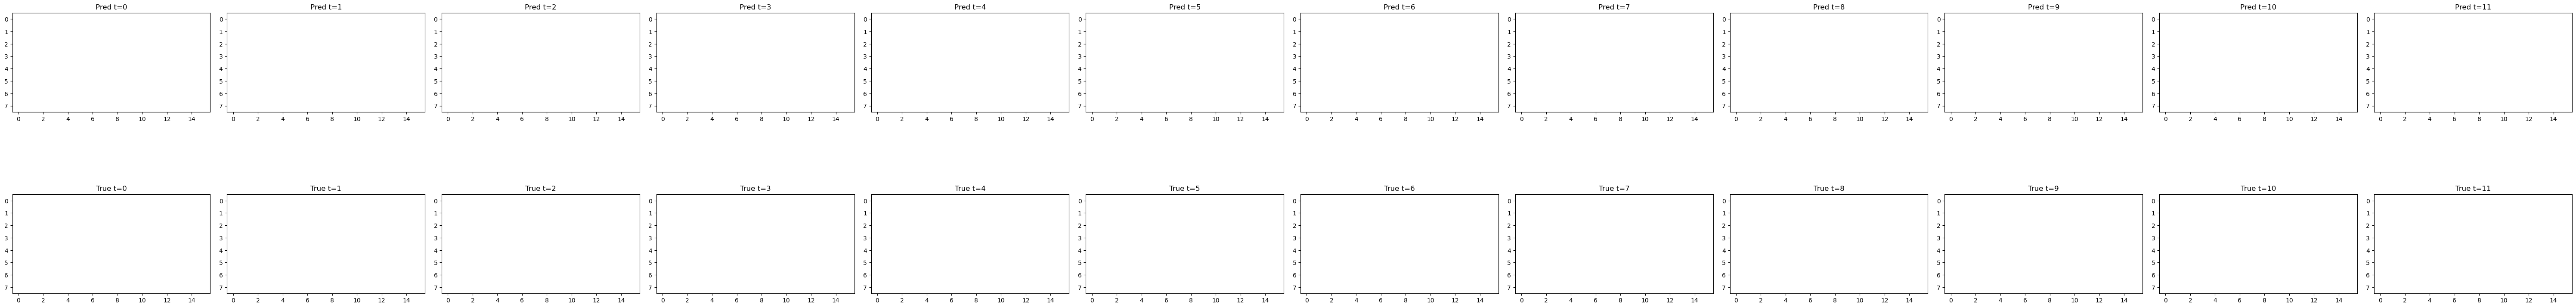

Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Accuracy: 0.9940
Confusion Matrix:
[[781704.0 0.0]
 [4728.0 0.0]]


In [ ]:
# Visualize
model = torch.load("./ee_dataset/best_model.pth")

visualize_sequence(model, train_loader)

# Get metrics
metrics = calculate_metrics(model, train_loader)